# 1.1 High Fidelity model runs

In [1]:
# Apply Autoreload so the script automatically detects changes in .py helper scripts

%load_ext autoreload
%autoreload 2

In [10]:
# IMport nescessary functions and helper functions

import os
import sys
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from typing import Union, List, Dict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from gan_pipeline.core import custom_plots as custom_plots
from postprocessing import PostProcessing
custom_plots.apply_custom_plotting_flavor()

In [7]:
# 1. Define the root project path
project_root = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM")

# 2. Define the primary sub-directories
base_datasets = project_root / "datasets" / "testing"
base_outputs = project_root / "outputs" / "post_training" / "20000_training_samples"
base_plots = project_root / "plots" / "post_training_plots"

# --- REAL DATA ---
data_dir = base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_6_isbx_100" / "samples" / "facies" / "*.npy"

output_dir_fac2 = base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80"

# --- GAN DATA ---
gan_data_dir_01 = base_outputs / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_02 = base_outputs / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_4_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_all = base_outputs / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings" / "realizations" / "*.npy"

# --- PLOT OUTPUTS TO ---
output_dir_gan_01 = base_plots / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_02 = base_plots / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_4_iter_setting_2"
output_dir_gan_all = base_plots / "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings" 

# --- POST PROCESSING / VALIDATORS ---
run_configs = [
    ("Run 1", "Model 5", output_dir_gan_01, gan_data_dir_01),
    ("Run 2", "Model 5 - all settings", output_dir_gan_all, gan_data_dir_all)
]

validators = []

# Loop through the configurations
for gan_name, gan_description, out_dir, gan_path in run_configs:
    
    # 1. Create directories if they don't exist
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize the validator
    if gan_name=="Run 2":
        nc = 3
    else:
        nc=9
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=data_dir,
        gan_path=gan_path,
        num_classes=nc
    )
    
    # 2. Load the samples
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    validators.append(validator)

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 1 samples (limit: 100)...
Loaded 100 Run 1 samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 2 samples (limit: 100)...
Loaded 100 Run 2 samples into memory.


## **MS-SWD**

In [11]:
def plot_ms_swd_progression(
    csv_path: Union[str, Path],
    output_dir: Union[str, Path],
    run_name: str,
    channels: list = None,
    epoch_lookback: int = 10,
    colors: dict = None,
    dpi: int = 300
) -> None:
    """
    Plots MS-SWD progression (Full Range vs Last N Epochs) and prints the metrics.
    """
    csv_path = Path(csv_path)
    output_dir = Path(output_dir)
    
    if not csv_path.exists():
        print(f"⚠️ Error: History file not found at: {csv_path}")
        return

    if channels is None:
        channels = ['MS-SWD_Ch0', 'MS-SWD_Ch1', 'MS-SWD_Ch2']
    if colors is None:
        colors = {
            'MS-SWD_Ch0': '#1f77b4',
            'MS-SWD_Ch1': '#ff7f0e',
            'MS-SWD_Ch2': '#2ca02c',
            'MS-SWD_Combined': '#d62728'
        }

    # Load and clean data
    df = pd.read_csv(csv_path)
    df.columns = [col.strip() for col in df.columns]

    epoch_col = next((c for c in ['epochs', 'epoch'] if c in df.columns), None)
    iter_col = next((c for c in ['iteration', 'iterations'] if c in df.columns), None)

    if not epoch_col or not iter_col:
        print(f"⚠️ Error: Could not find epoch/iteration columns in {csv_path.name}")
        return

    # Filter columns
    existing_channels = [ch for ch in channels if ch in df.columns]
    if not existing_channels:
        print(f"⚠️ Error: None of the target channels are present in {csv_path.name}")
        return

    df_metrics = df.dropna(subset=existing_channels).copy()
    if df_metrics.empty:
        print(f"⚠️ Error: No valid numeric metrics found in {csv_path.name}")
        return

    # Calculate combined channel metric
    df_metrics['MS-SWD_Combined'] = df_metrics[existing_channels].mean(axis=1)
    all_metrics = existing_channels + ['MS-SWD_Combined']

    # Filter for last N epochs
    max_epoch = df_metrics[epoch_col].max()
    df_last_n = df_metrics[df_metrics[epoch_col] >= (max_epoch - epoch_lookback)].copy()

    # Print Means directly to console
    print("\n" + "=" * 60)
    print(f" METRIC SUMMARY FOR RUN: {run_name} ".center(60, "="))
    print("=" * 60)
    
    print("\n--- Full Range Mean Metrics ---")
    full_means = {}
    for col in all_metrics:
        mean_val = df_metrics[col].mean()
        full_means[col] = mean_val
        print(f"  * {col:<20} : {mean_val:.6f}")

    print(f"\n--- Last {epoch_lookback} Epochs Mean Metrics (Epochs {int(max_epoch - epoch_lookback)} to {int(max_epoch)}) ---")
    last_n_means = {}
    if not df_last_n.empty:
        for col in all_metrics:
            mean_val = df_last_n[col].mean()
            last_n_means[col] = mean_val
            print(f"  * {col:<20} : {mean_val:.6f}")
    else:
        print("  [No data available in this epoch range]")
    print("=" * 60 + "\n")

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Left Plot: Full Range
    ax1 = axes[0]
    for col in all_metrics:
        label_short = col.replace('MS-SWD_', '')
        color = colors.get(col, '#7f7f7f')
        mean_val = full_means[col]
        
        ax1.plot(df_metrics[iter_col], df_metrics[col], color=color, linewidth=1.5, alpha=0.8)
        ax1.axhline(mean_val, color=color, linestyle='--', linewidth=1.2, alpha=0.7,
                    label=f"{label_short} (Mean: {mean_val:.4f})")
        
    ax1.set_title(f"MS-SWD Progression (Full Range)\n{run_name}", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Iterations", fontsize=10)
    ax1.set_ylabel("MS-SWD Value", fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    
    # Right Plot: Zoomed last N Epochs
    ax2 = axes[1]
    if not df_last_n.empty:
        for col in all_metrics:
            label_short = col.replace('MS-SWD_', '')
            color = colors.get(col, '#7f7f7f')
            mean_val_ln = last_n_means[col]
            
            ax2.plot(df_last_n[iter_col], df_last_n[col], color=color, linewidth=1.5, alpha=0.8)
            ax2.axhline(mean_val_ln, color=color, linestyle='--', linewidth=1.2, alpha=0.7,
                        label=f"{label_short} (Mean: {mean_val_ln:.4f})")
            
        ax2.set_title(f"MS-SWD Progression (Last {epoch_lookback} Epochs)\n{run_name}", fontsize=12, fontweight='bold')
        ax2.set_xlabel("Iterations", fontsize=10)
        ax2.grid(True, linestyle=':', alpha=0.6)
        ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
    else:
        ax2.text(0.5, 0.5, "Insufficient data for evaluation", ha='center', va='center', transform=ax2.transAxes, color='gray')
        ax2.set_title(f"MS-SWD Progression (Last {epoch_lookback} Epochs)", fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    output_dir.mkdir(parents=True, exist_ok=True)
    sanitized_name = run_name.lower().replace(":", "").replace(" ", "_")
    plot_path = output_dir / f"ms_swd_progression_{sanitized_name}.png"
    
    plt.savefig(plot_path, dpi=dpi, bbox_inches='tight')
    plt.close()
    print(f"Successfully saved plot to: {plot_path}")

In [12]:
validators = []

# Possible file names for history CSV files
potential_csv_names = [
    "fluvgan_1_training_1_architecture_4_dcgan_one_hot_all_1_history.csv",  # 9 classes
    "fluvgan_1_training_1_architecture_4_dcgan_one_hot_1_history.csv"       # 3 classes
]

for gan_name, gan_description, out_dir, gan_path in run_configs:
    # 1. Create directory
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize and load samples
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=data_dir,
        gan_path=gan_path
    )
    
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    
    # 3. Resolve the history CSV dynamically by probing both file options
    run_dir = Path(gan_path).parent.parent
    csv_history_path = None
    
    for filename in potential_csv_names:
        temp_path = run_dir / filename
        if temp_path.exists():
            csv_history_path = temp_path
            break
            
    if csv_history_path is not None:
        # 4. Generate the plot and print metrics
        plot_ms_swd_progression(
            csv_path=csv_history_path,
            output_dir=out_dir,
            run_name=gan_name,
            epoch_lookback=10
        )
    else:
        print(f"⚠️ Warning: No history file found in {run_dir} (tried {potential_csv_names})")
    
    # 5. MEMORY CRITICAL FIX: 
    # If you only need validator objects for final summary stats or plotting references,
    # free the massive raw numpy arrays so Python doesn't crash on subsequent loop runs.
    validator.flumy_data = None
    validator.gan_data = None
    
    validators.append(validator)
    
    # Explicitly trigger garbage collection
    #gc.collect()

print("\nPipeline execution finished cleanly!")

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 1 samples (limit: 100)...
Loaded 100 Run 1 samples into memory.

============== METRIC SUMMARY FOR RUN: Run 1 ===============

--- Full Range Mean Metrics ---
  * MS-SWD_Ch0           : 0.114776
  * MS-SWD_Ch1           : 0.074304
  * MS-SWD_Ch2           : 0.110252
  * MS-SWD_Combined      : 0.099777

--- Last 10 Epochs Mean Metrics (Epochs 15 to 25) ---
  * MS-SWD_Ch0           : 0.067443
  * MS-SWD_Ch1           : 0.041417
  * MS-SWD_Ch2           : 0.079396
  * MS-SWD_Combined      : 0.062752

Successfully saved plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\ms_swd_progression_run_1.png
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 2 samples (limit: 100)...
Loaded 10

# **1. Global Facies proportions**

Loading Run 1 samples (limit: 100)...
Loaded 100 Run 1 samples into memory.

--- Generating Facies Distribution (Mode: BOTH) ---
saved both facies percentages plot to: 
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\facies_distribution_both.png


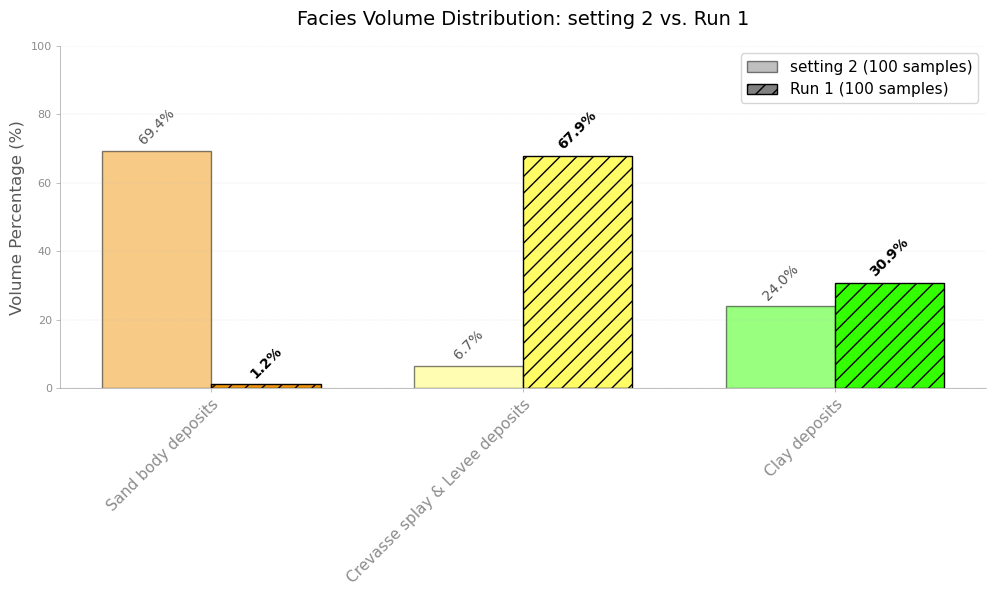

Loading Run 2 samples (limit: 100)...
Loaded 100 Run 2 samples into memory.

--- Generating Facies Distribution (Mode: BOTH) ---
saved both facies percentages plot to: 
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\facies_distribution_both.png


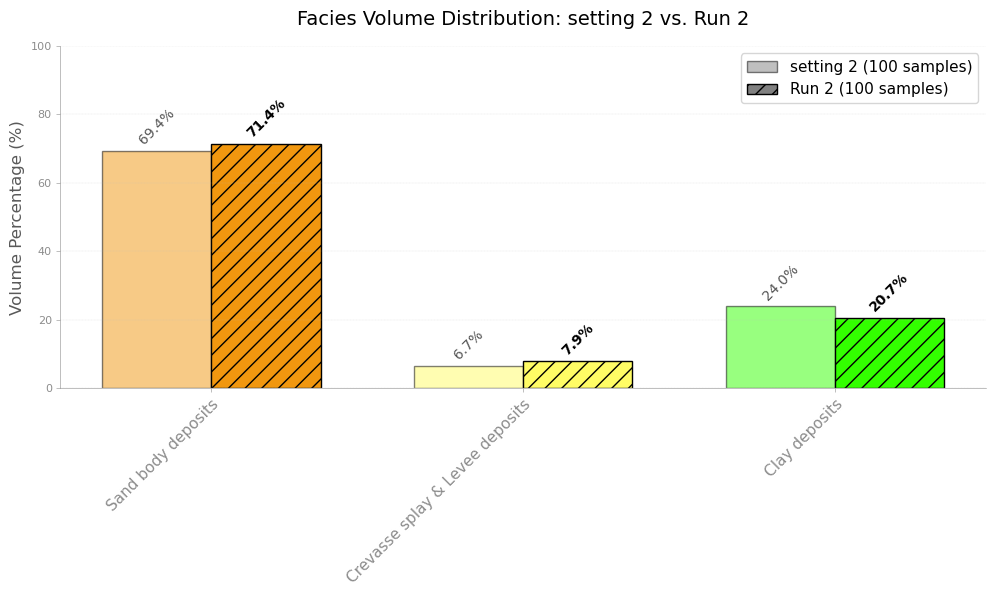

In [13]:
for validator in validators:
    validator.plot_facies_percentages(mode="both",save_plot=True)

# **2. Visualization**

## **2.1 2D Visualization**

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_flumy_Z_3samples.png


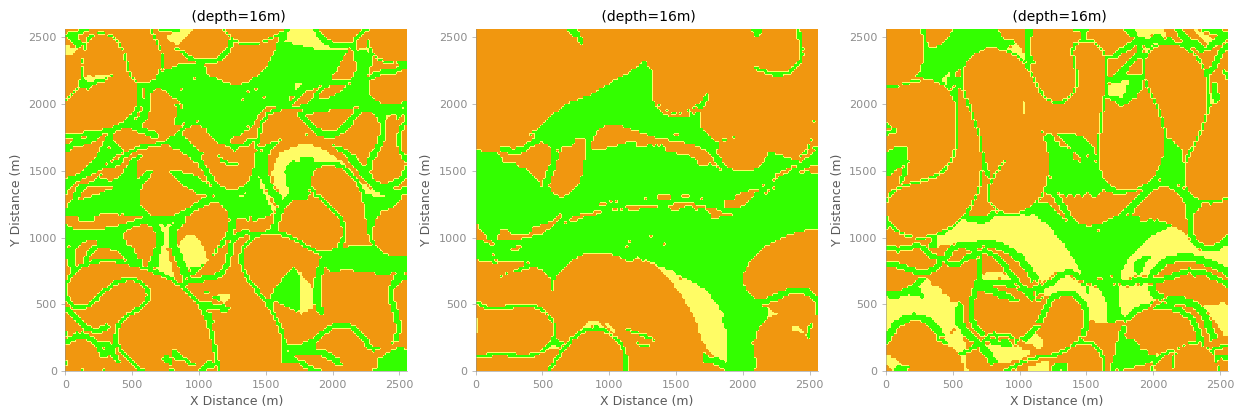

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_flumy_X_3samples.png


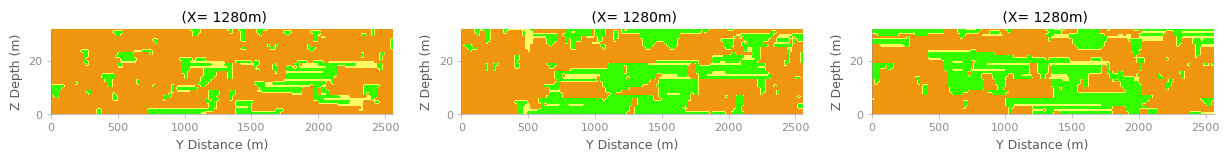

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_flumy_Y_3samples.png


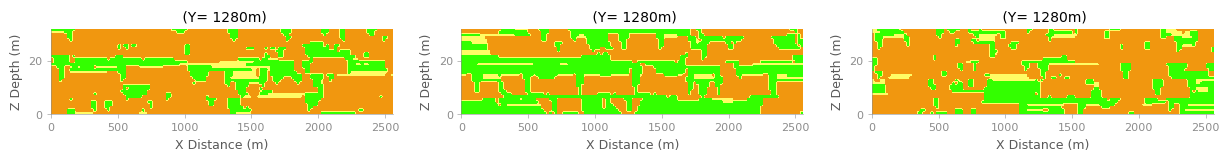

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_Z_3samples.png


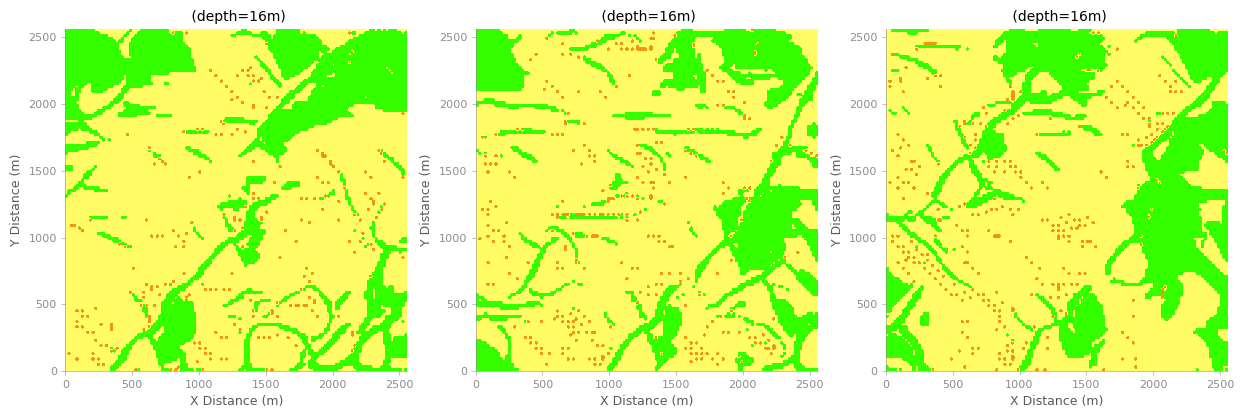

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_X_3samples.png


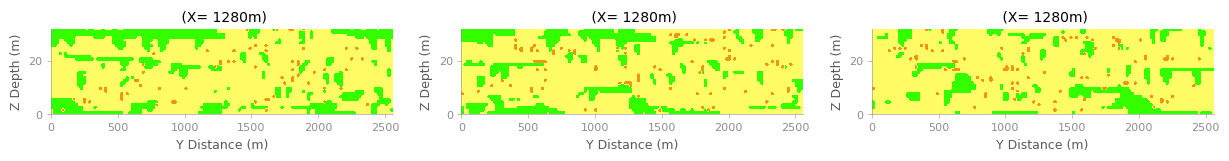

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\combined_grid_gan_Y_3samples.png


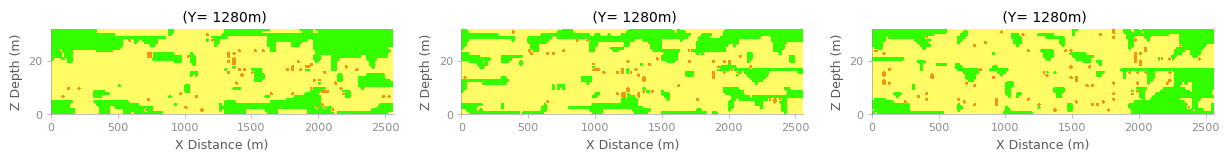

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\combined_grid_flumy_Z_3samples.png


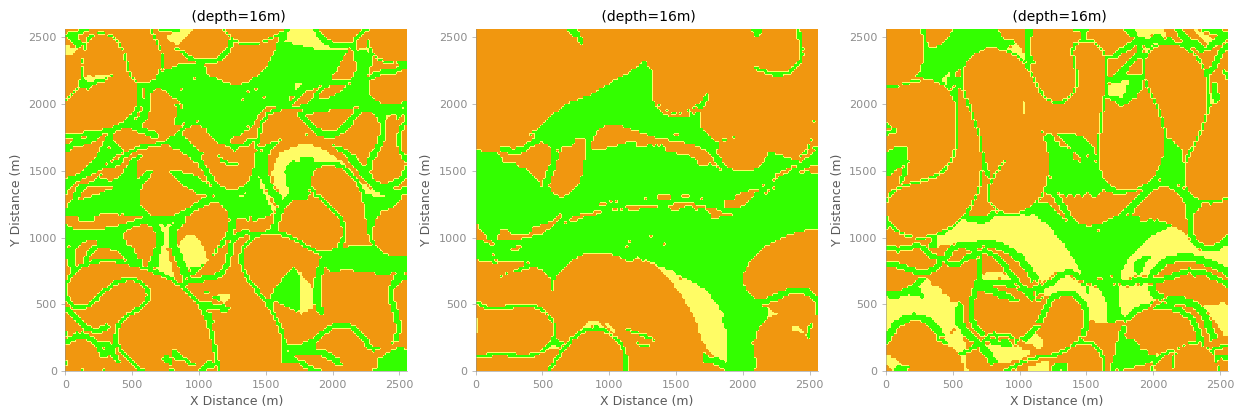

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\combined_grid_flumy_X_3samples.png


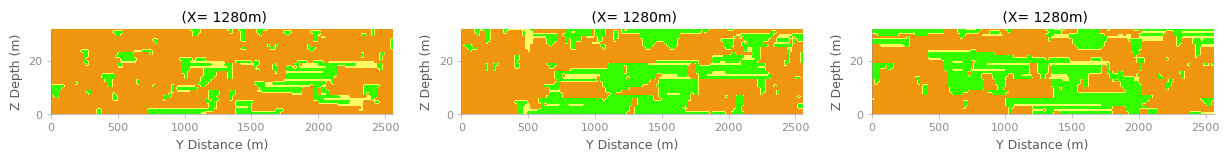

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\combined_grid_flumy_Y_3samples.png


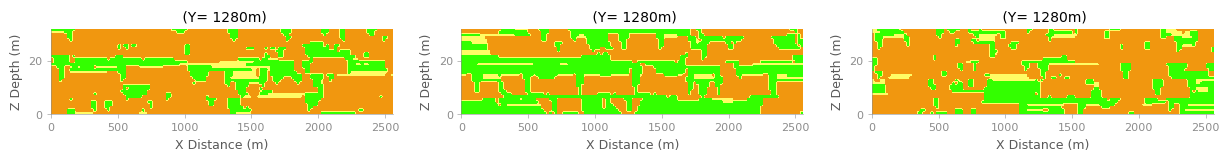

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\combined_grid_gan_Z_3samples.png


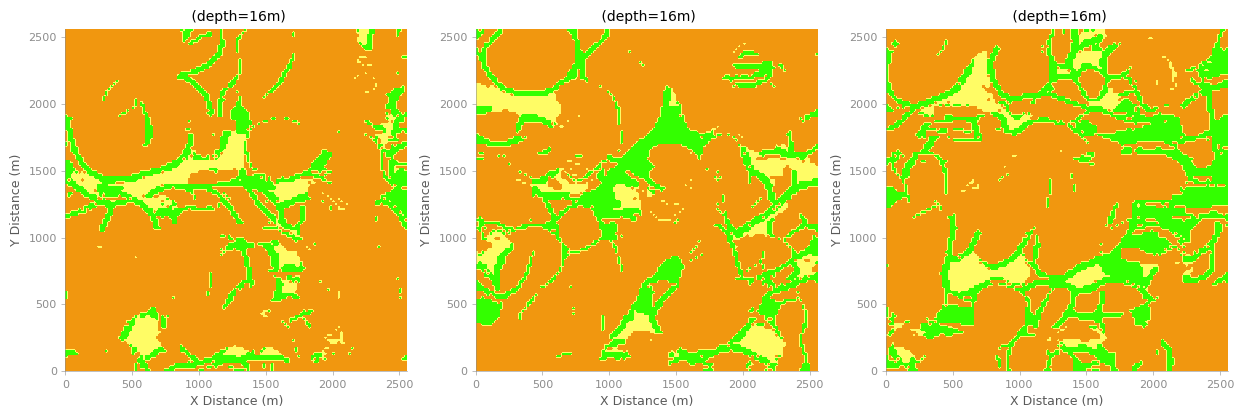

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\combined_grid_gan_X_3samples.png


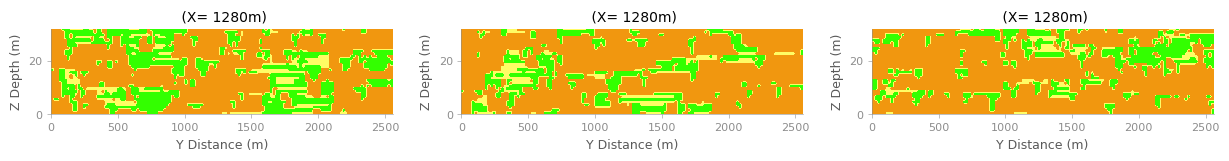

Saved combined 2D grid matrix to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\combined_grid_gan_Y_3samples.png


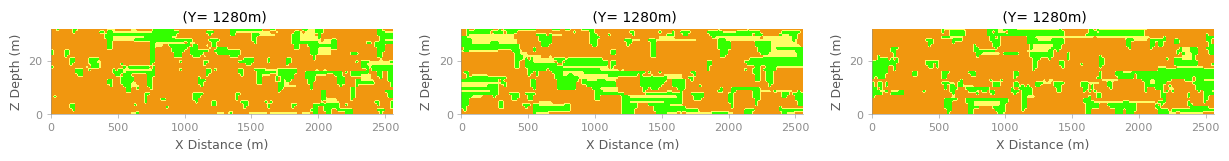

In [14]:
for i, validator in enumerate(validators):
    validator.plot_2d_slices(data_source='flumy', axis="Z", show_legend=False, plot_filename=False, plot_title=False, num_samples=3, slice_indices=[16], save_plot=True)
    validator.plot_2d_slices(data_source='flumy', axis="X", show_legend=False, plot_filename=False, plot_title=False, num_samples=3, slice_indices=[64], save_plot=True)
    validator.plot_2d_slices(data_source='flumy', axis="Y", show_legend=False, plot_filename=False, plot_title=False, num_samples=3, slice_indices=[64], save_plot=True)
    validator.plot_2d_slices(data_source='gan', axis="Z", show_legend=False, plot_title=False, plot_filename=False, num_samples=3, slice_indices=[16], save_plot=True)
    validator.plot_2d_slices(data_source='gan', axis="X", show_legend=False, plot_title=False, plot_filename=False, num_samples=3, slice_indices=[64], save_plot=True)
    validator.plot_2d_slices(data_source='gan', axis="Y", show_legend=False, plot_title=False, plot_filename=False, num_samples=3, slice_indices=[64], save_plot=True)

## **2.2. 3D Visualization**


--- Generating 3D PyVista Plot (Run 1 | Mode: COMBINED) ---


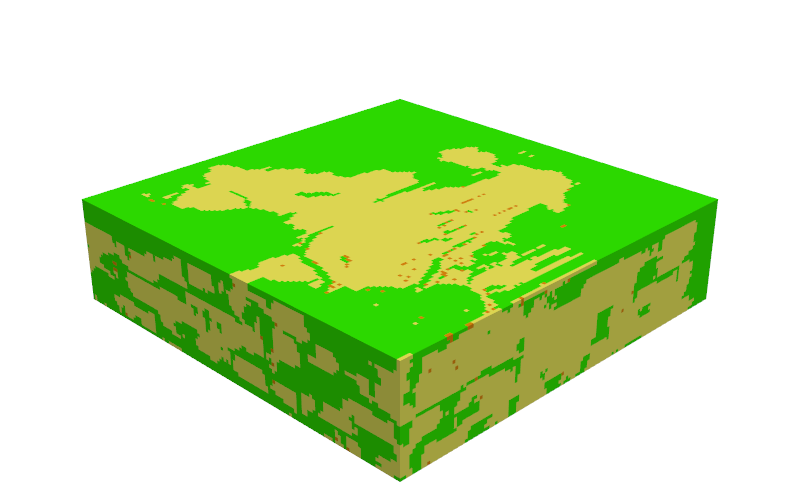

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2\3d_plot_gan_sample_73combined.png

--- Generating 3D PyVista Plot (Run 2 | Mode: COMBINED) ---


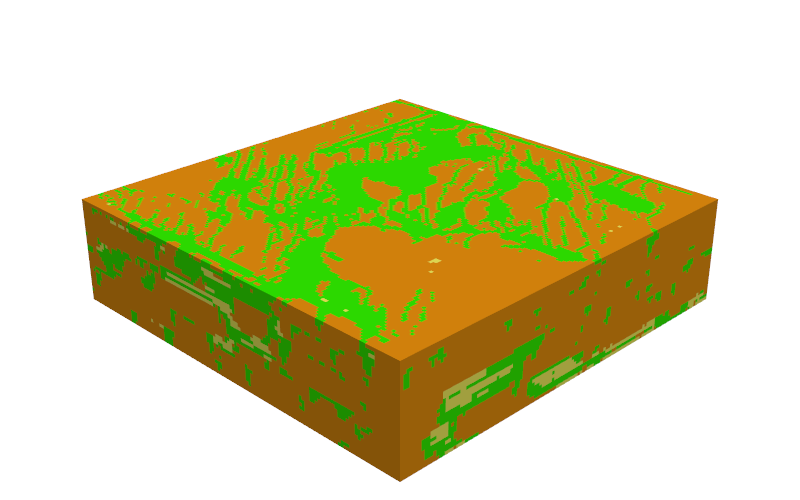

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings\3d_plot_gan_sample_88combined.png


In [15]:
for i, validator in enumerate(validators):
    validator.plot_3d_pyvista(mode="combined",show_legend=False)

# **3. Voxel-wise entropy($H$)**

## **3.1 2D Voxel-wise $H$**

Plotting 2d slices of FLUMY test dataset

--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


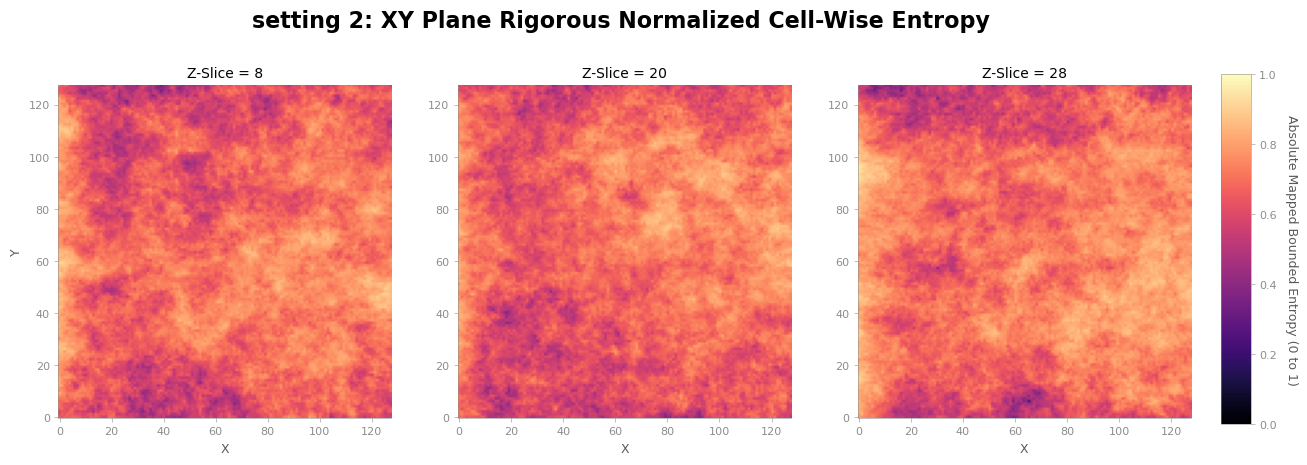


--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


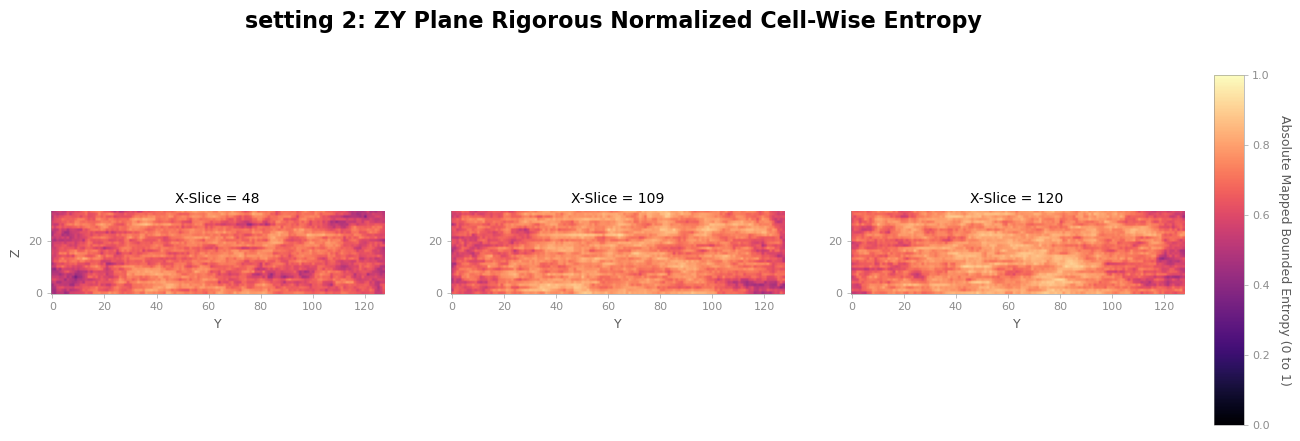


--- Generating setting 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


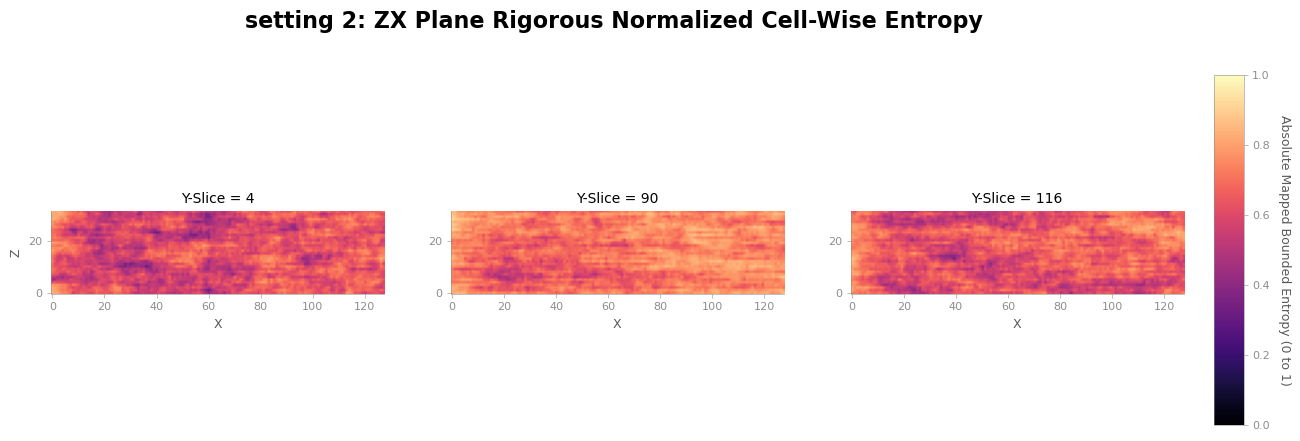


--- Generating Run 1 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


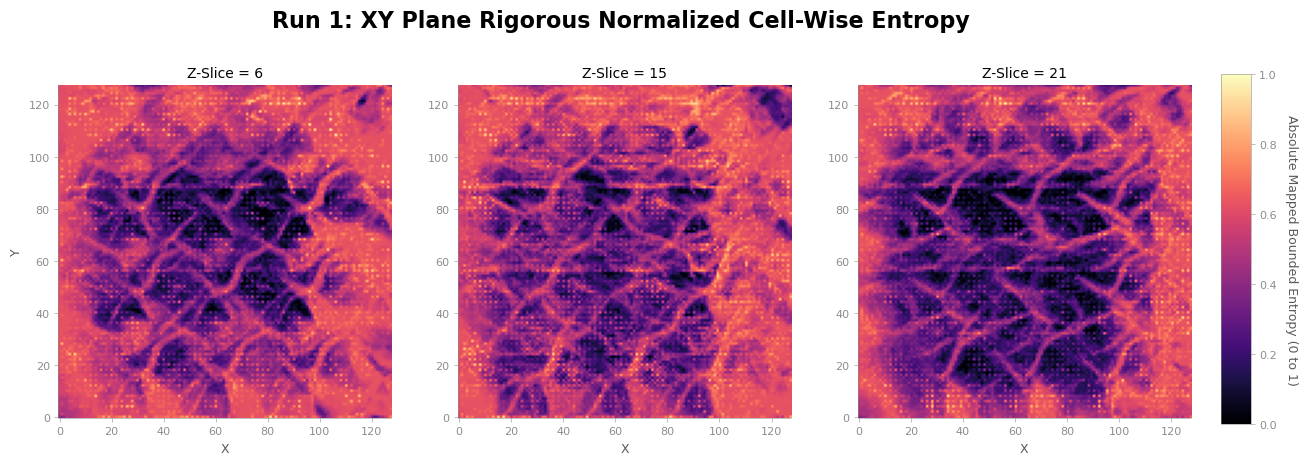


--- Generating Run 1 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


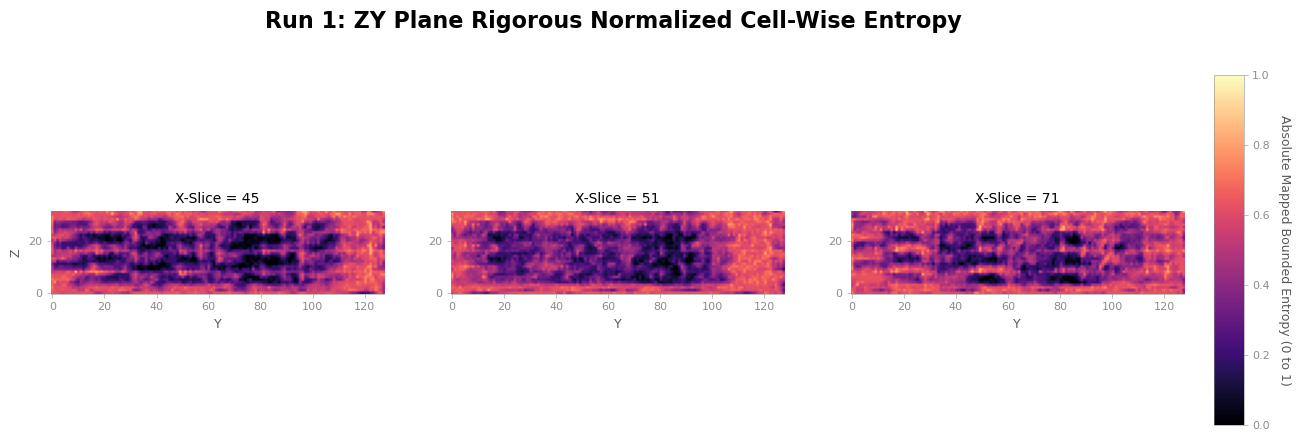


--- Generating Run 1 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


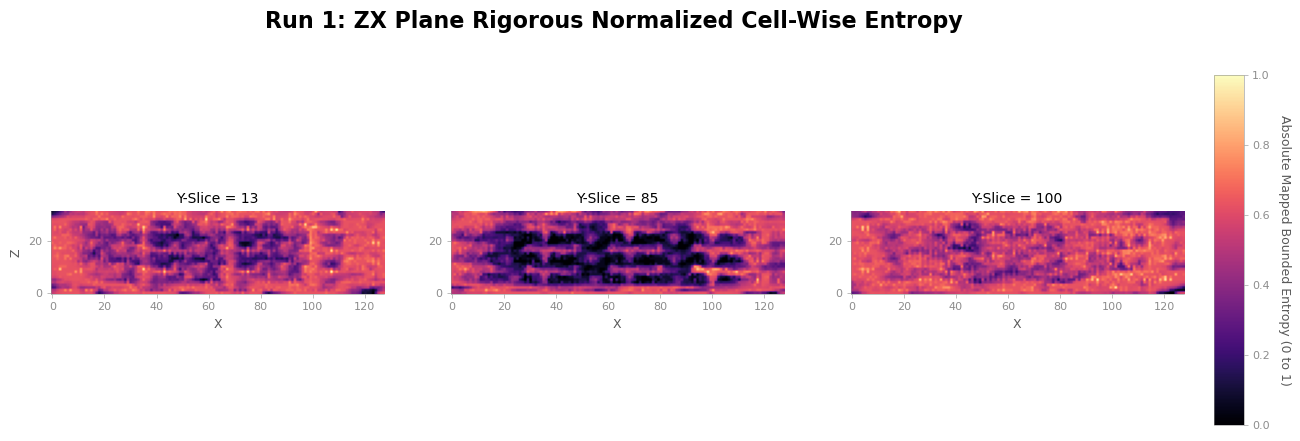


--- Generating Run 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


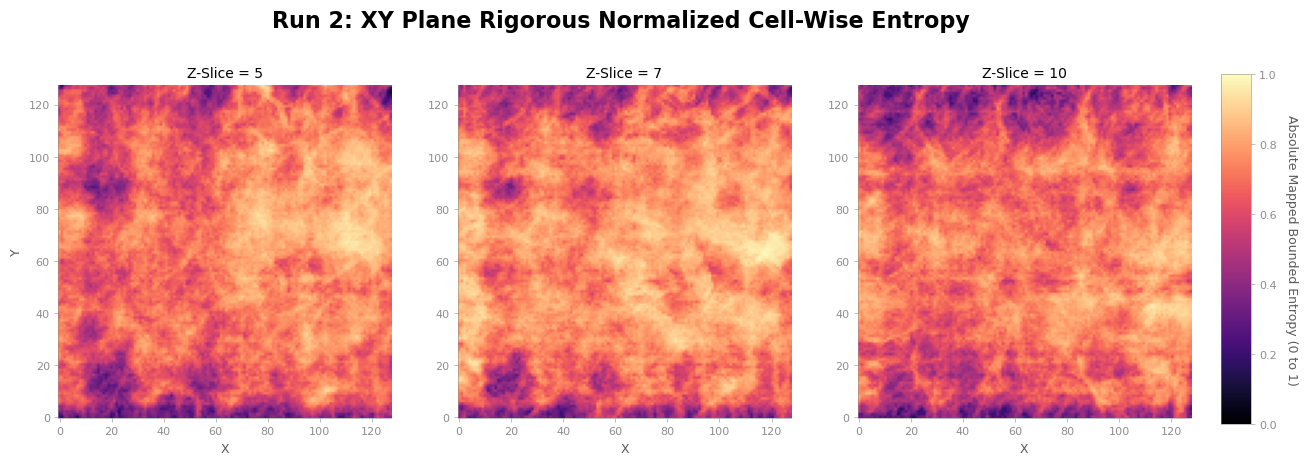


--- Generating Run 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


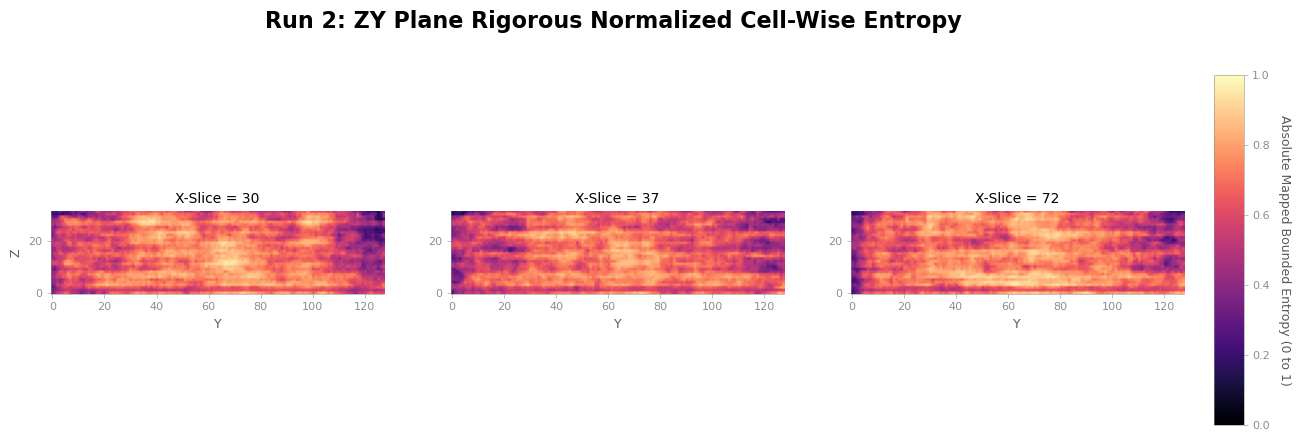


--- Generating Run 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


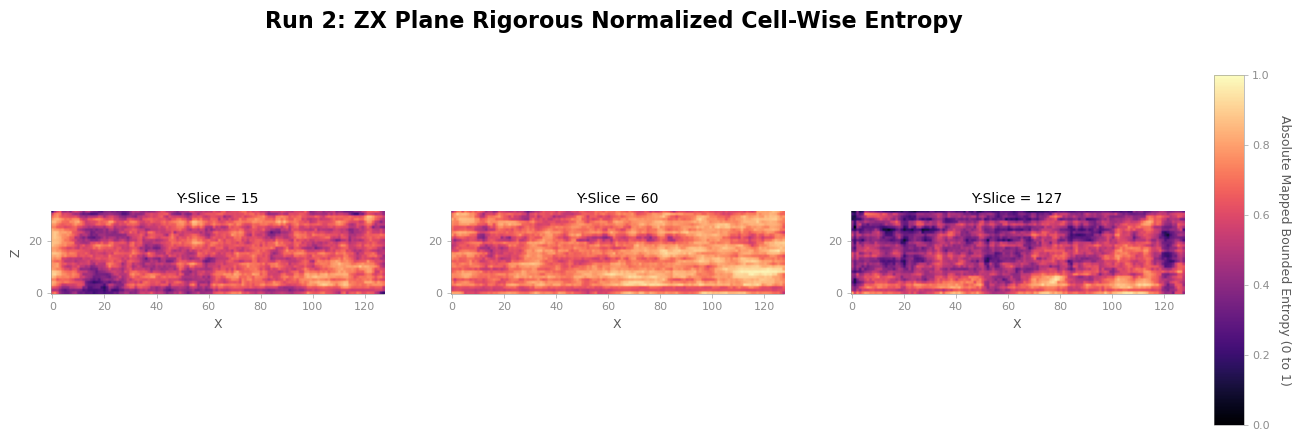

In [16]:
for i, validator in enumerate(validators):
    if i ==0:
        print(f"Plotting 2d slices of FLUMY test dataset")
        validator.plot_entropy(data_source='flumy', axis='Z', num_slices=3, save_plot=False)
        validator.plot_entropy(data_source='flumy', axis='X', num_slices=3, save_plot=False)
        validator.plot_entropy(data_source='flumy', axis='Y', num_slices=3, save_plot=False)

    validator.plot_entropy(data_source='gan', axis='Z', num_slices=3, save_plot=False)
    validator.plot_entropy(data_source='gan', axis='X', num_slices=3, save_plot=False)
    validator.plot_entropy(data_source='gan', axis='Y', num_slices=3, save_plot=False)

## **3.1 3D Voxel-wise $H$**


--- Generating 3D PyVista Entropy Map (setting 2) ---
[setting 2] Calculated Mean Voxel-Wise Entropy: 0.6922


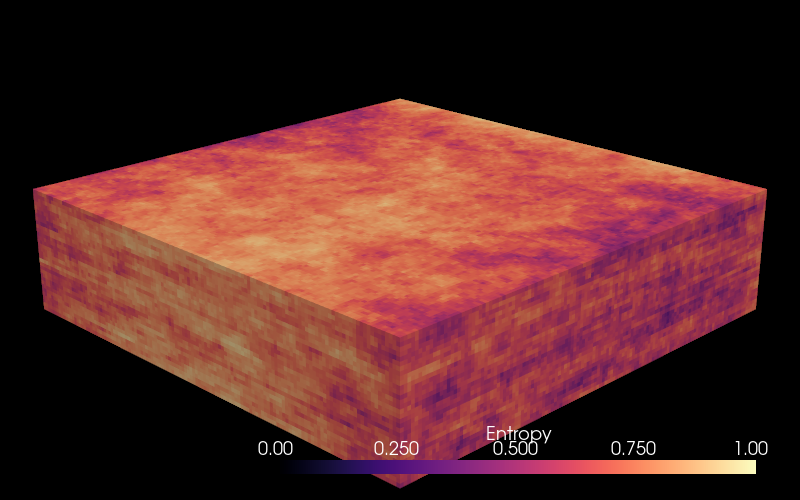


--- Generating 3D PyVista Entropy Map (Run 1) ---
[Run 1] Calculated Mean Voxel-Wise Entropy: 0.4902


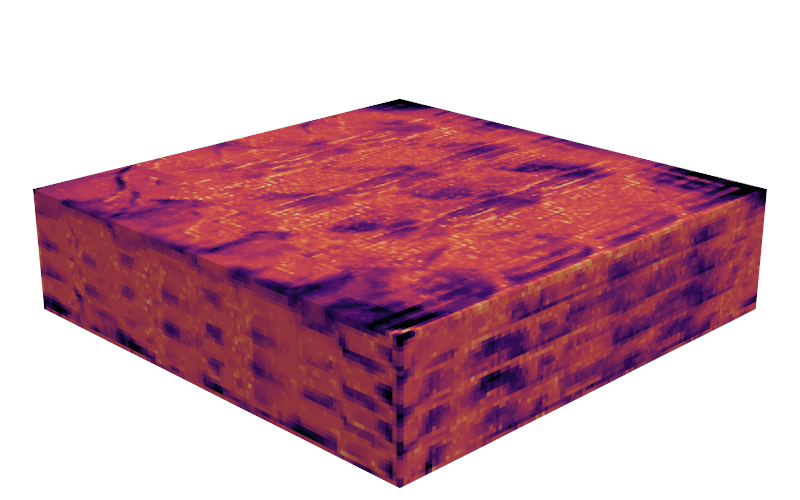


--- Generating 3D PyVista Entropy Map (Run 2) ---
[Run 2] Calculated Mean Voxel-Wise Entropy: 0.6614


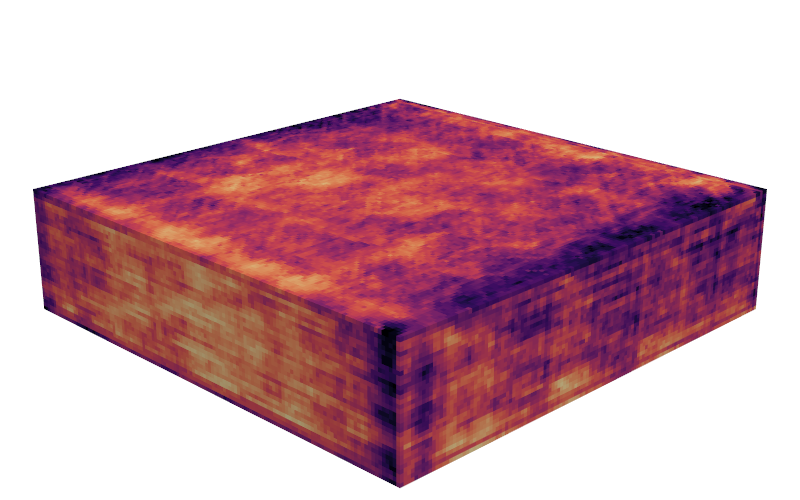

In [17]:
for i, validator in enumerate(validators):
    if i == 0:
        validator.plot_3d_entropy_pyvista(data_source='flumy')
    validator.plot_3d_entropy_pyvista(show_legend=False, save_plot=True, black_background=False)

## **2.3. JSD**


--- Computing Scalar Metrics comparing Run 1 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 1 Model Entropy:  0.4902 ± 0.0567
Model-to-Baseline Spatial Entropy Ratio: 0.7082
Model-to-baseline JSD: 0.5740 ± 0.0397

--- Computing Scalar Metrics comparing Run 2 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0099
Run 2 Model Entropy:  0.6614 ± 0.0488
Model-to-Baseline Spatial Entropy Ratio: 0.9555
Model-to-baseline JSD: 0.0168 ± 0.0071


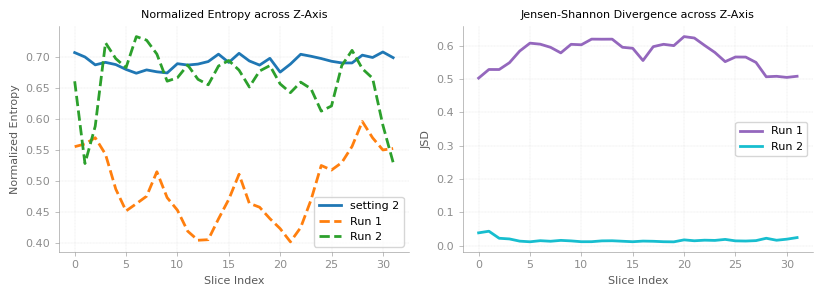


--- Computing Scalar Metrics comparing Run 1 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
Run 1 Model Entropy:  0.4902 ± 0.0520
Model-to-Baseline Spatial Entropy Ratio: 0.7082
Model-to-baseline JSD: 0.5740 ± 0.0544

--- Computing Scalar Metrics comparing Run 2 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0381
Run 2 Model Entropy:  0.6614 ± 0.0475
Model-to-Baseline Spatial Entropy Ratio: 0.9555
Model-to-baseline JSD: 0.0168 ± 0.0019


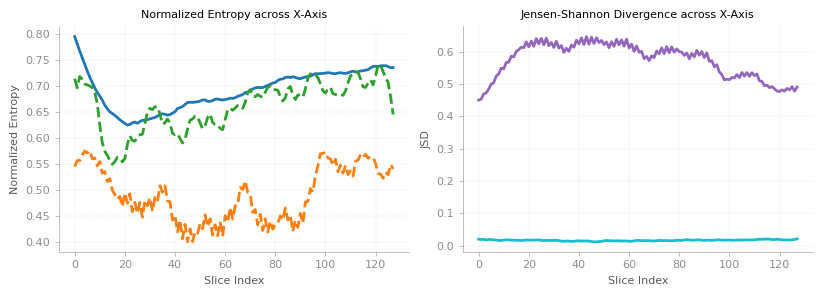


--- Computing Scalar Metrics comparing Run 1 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
Run 1 Model Entropy:  0.4902 ± 0.0515
Model-to-Baseline Spatial Entropy Ratio: 0.7082
Model-to-baseline JSD: 0.5740 ± 0.0241

--- Computing Scalar Metrics comparing Run 2 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6922 ± 0.0461
Run 2 Model Entropy:  0.6614 ± 0.0952
Model-to-Baseline Spatial Entropy Ratio: 0.9555
Model-to-baseline JSD: 0.0168 ± 0.0028


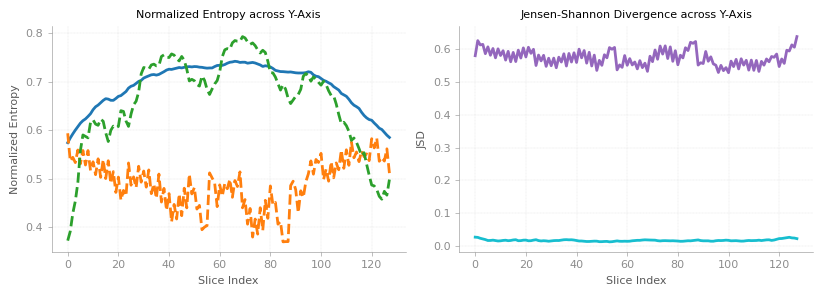

In [18]:
import matplotlib.pyplot as plt

axes_to_plot = ['Z', 'X', 'Y']

for i, axis in enumerate(axes_to_plot):
    fig, fig_axes = plt.subplots(1, 2, figsize=(8.27, 3))
    
    baseline_plotted = False
    gan_colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:brown']
    jsd_colors = ['tab:purple', 'tab:cyan', 'tab:pink', 'tab:olive']
    
    for idx, validator in enumerate(validators):
        df_results, _ = validator.compute_slice_metrics(axis=axis, plot=False)
        
        slices = df_results['Slice_Index']
        flumy_entropy = df_results['Flumy_Norm_Entropy']
        gan_entropy = df_results['GAN_Norm_Entropy']
        jsd = df_results['JSD_Flumy_vs_GAN']
        
        if not baseline_plotted:
            fig_axes[0].plot(slices, flumy_entropy, label=validator.flumy_name, color='tab:blue', linewidth=2)
            baseline_plotted = True
            
        g_color = gan_colors[idx % len(gan_colors)]
        fig_axes[0].plot(slices, gan_entropy, label=f'{validator.gan_name}', color=g_color, linewidth=2, linestyle='--')
        
        j_color = jsd_colors[idx % len(jsd_colors)]
        fig_axes[1].plot(slices, jsd, label=f'{validator.gan_name}', color=j_color, linewidth=2)
        
    fig_axes[0].set_title(f'Normalized Entropy across {axis}-Axis', fontsize=8)
    fig_axes[0].set_xlabel('Slice Index', fontsize=8)
    fig_axes[0].set_ylabel('Normalized Entropy', fontsize=8)
    if i ==0:
        fig_axes[0].legend(fontsize=8)
    fig_axes[0].grid(True, linestyle='--', alpha=0.7)
    
    fig_axes[1].set_title(f'Jensen-Shannon Divergence across {axis}-Axis', fontsize=8)
    fig_axes[1].set_xlabel('Slice Index', fontsize=8)
    fig_axes[1].set_ylabel('JSD', fontsize=8)
    if i == 0:
        fig_axes[1].legend(fontsize=8)
    fig_axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'combined_H_and_JSD_metrics_axis_{axis}.png', dpi=300)
    plt.show()

In [19]:
import gc
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

first_val = validators[0]
facies_list = first_val.cfg['codes']
flumy_name = first_val.flumy_name

blob_data_compiled = {f_val: {} for f_val in facies_list}
unique_pattern_counts = {}
baseline_patterns_computed = False

for validator in validators:
    if not getattr(validator, 'flumy_samples', None):
        validator.load_flumy_samples(limit=100)
    if not getattr(validator, 'gan_data', None):
        validator.load_gan_samples(limit=100)
        
    if not baseline_patterns_computed:
        flumy_pattern_set = set()
        for sample in validator.flumy_samples[:100]:
            patterns, _ = validator.get_pattern_counts(sample)
            for p in patterns:
                flumy_pattern_set.add(tuple(p))
        unique_pattern_counts[flumy_name] = len(flumy_pattern_set)
        del flumy_pattern_set
        gc.collect()
        baseline_patterns_computed = True

    gan_pattern_set = set()
    for sample in validator.gan_data[:100]:
        patterns, _ = validator.get_pattern_counts(sample)
        for p in patterns:
            gan_pattern_set.add(tuple(p))
    unique_pattern_counts[validator.gan_name] = len(gan_pattern_set)
    del gan_pattern_set
    gc.collect()
        
    for f_val in facies_list:
        if flumy_name not in blob_data_compiled[f_val]:
            flumy_blobs = []
            for sample in validator.flumy_samples[:100]:
                flumy_blobs.extend(validator.analyze_connectivity(sample, f_val))
            blob_data_compiled[f_val][flumy_name] = flumy_blobs
            
        gan_blobs = []
        for sample in validator.gan_data[:100]:
            gan_blobs.extend(validator.analyze_connectivity(sample, f_val))
        blob_data_compiled[f_val][validator.gan_name] = gan_blobs
        
    validator.flumy_samples = []
    validator.gan_data = []
    gc.collect()

print("\n" + "="*50)
print(" TOTAL UNIQUE MPS PATTERNS (100 SAMPLES)")
print("="*50)
for name, count in unique_pattern_counts.items():
    print(f"{name}: {count:,} unique patterns")
print("="*50 + "\n")

dataset_names = [flumy_name] + [v.gan_name for v in validators]
color_sequence = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
color_palette = {name: color_sequence[i % len(color_sequence)] for i, name in enumerate(dataset_names)}

fig, axes = plt.subplots(1, 3, figsize=(8.27, 3.5))

for idx, f_val in enumerate(facies_list):
    ax = axes[idx]
    facies_name = first_val.cfg['names'].get(f_val, f"Facies {f_val}")
    
    flat_list = []
    for d_name in dataset_names:
        for size in blob_data_compiled[f_val].get(d_name, []):
            flat_list.append({'Blob_Size': size, 'Dataset': d_name})
            
    df_blobs = pd.DataFrame(flat_list)
    
    if not df_blobs.empty:
        sns.histplot(
            data=df_blobs,
            x='Blob_Size',
            hue='Dataset',
            palette=color_palette,
            kde=True,
            element='step',
            stat='density',
            common_norm=False,
            alpha=0.3,
            ax=ax,
            log_scale=True,
            legend=False
        )
    
    ax.set_title(facies_name, fontsize=10)
    ax.set_xlabel("Blob Size (voxels)", fontsize=9)
    ax.set_ylabel("Density" if idx == 0 else "", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

fig.subplots_adjust(left=0.08, right=0.96, wspace=0.32, bottom=0.26, top=0.88)

legend_handles = [
    mpatches.Patch(color=color_palette[name], label=name, alpha=0.4) 
    for name in dataset_names
]

fig.legend(
    handles=legend_handles, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.15), 
    ncol=len(dataset_names), 
    frameon=True, 
    fontsize=9
)

plt.savefig("combined_models_facies_connectivity_analysis.png", dpi=300)
plt.show()

KeyboardInterrupt: 

# **Figure 4.6: MS-SWD evolution**

In [21]:
def plot_metric_history_all_classes(ax, csv_path, run_name):
    """Parses training logs, dynamically handles plotting for N classes, and displays the mean DW value."""
    if not os.path.exists(csv_path):
        ax.text(0.5, 0.5, "Missing History Log", ha='center', va='center', color='orange', fontsize=6)
        ax.axis('off')
        print(f"[{run_name}] Missing History Log - Cannot compute mean SWD")
        return None

    try:
        df = pd.read_csv(csv_path)
        
        # 1. Dynamically find all metric columns (e.g., MS-SWD_Ch0, MS-SWD_Ch1, ..., MS-SWD_Ch8)
        metric_cols = [col for col in df.columns if col.startswith('MS-SWD_Ch')]
        if not metric_cols:
            raise ValueError("No matching 'MS-SWD_Ch' columns found in the CSV.")
            
        # Sort columns to ensure they plot sequentially (Ch0, Ch1, Ch2...)
        metric_cols = sorted(metric_cols, key=lambda x: [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', x)])
        
        # 2. Coerce metric columns to numeric
        for col in metric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Drop rows where the first metric is NaN to cleanly connect validation points
        df_metrics = df.dropna(subset=[metric_cols[0]])
        x_axis = 'iteration'
        
        # 3. Dynamically calculate overall mean SWD across all discovered channels
        channel_means = [df_metrics[col].mean() for col in metric_cols]
        mean_swd = np.mean(channel_means)
        
        # 4. Generate colors dynamically using a matplotlib colormap (handles 3, 9, or N classes beautifully)
        # 'tab10' works perfectly for up to 10 classes. If you have more, 'viridis' or 'plasma' are great alternatives.
        cmap = plt.get_cmap('tab10') 
        
        lines = []
        for i, col in enumerate(metric_cols):
            color = cmap(i % 10)  # Cycles if classes exceed 10
            line, = ax.plot(
                df_metrics[x_axis], 
                df_metrics[col], 
                color=color, 
                linewidth=1.0, 
                markersize=1.5,
                label=col.split('_')[-1] # e.g., 'Ch0', 'Ch1' (useful if you add a legend later)
            )
            lines.append(line)
        
        # Axis titles and inline metrics placement
        ax.set_title(run_name, fontsize=7, pad=4, loc='left')
        ax.text(1.0, 1.05, f"mean $d_w$ = {mean_swd:.3f}", fontsize=6.5, color='#595959', ha='right', va='baseline', transform=ax.transAxes)
        
        ax.legend(
            handles=lines,
            loc='upper right',
            bbox_to_anchor=(0.95, 0.95),  # Keeps it cleanly inside the plot box
            ncol=3,                       # 3x3 grid looks compact and neat inside the axis
            fontsize=5,
            frameon=True,
            facecolor='white',
            edgecolor='#e0e0e0',
            framealpha=0.9,               # Slightly translucent so gridlines behind it show faintly
            handlelength=1.2,
            handletextpad=0.4,
            columnspacing=0.8
        )

        ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.tick_params(axis='both', which='major', labelsize=5.5, pad=2)
        
        return lines
        
    except Exception as e:
        ax.text(0.5, 0.5, "Error Processing CSV", ha='center', va='center', color='red', fontsize=6)
        ax.axis('off')
        print(f"[{run_name}] Error processing CSV: {str(e)}")
        return None

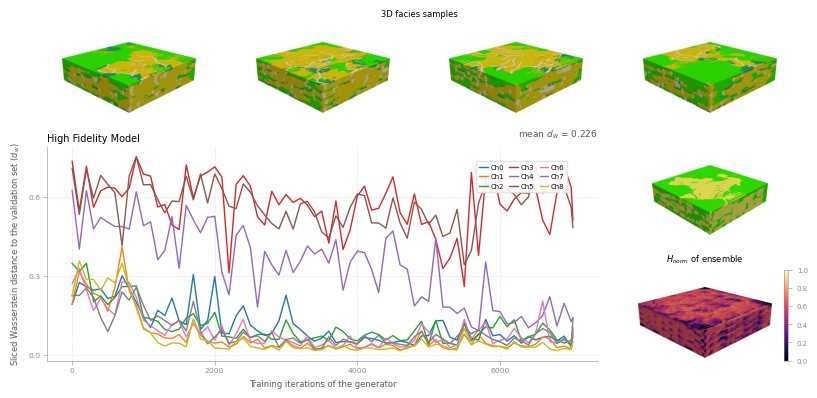

In [22]:
import os
import re
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg

# 1. Path definition
output_dir_HF = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
gan_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
absolute_csv_path = os.path.abspath(os.path.join(gan_dir, "fluvgan_1_training_1_architecture_4_dcgan_one_hot_all_1_history.csv"))

# 2. Create figure
fig = plt.figure(figsize=(8.27, 4))
gs = gridspec.GridSpec(nrows=3, ncols=4)
gs.update(hspace=0.35, wspace=0.18, bottom=0.08, top=0.92, left=0.05, right=0.95) # Slightly increased hspace for titles

# 4. Gather all available sample images
img_pattern = os.path.join(output_dir_HF, "3d_plot_gan_sample_*combined.png")
entropy_pattern = os.path.join(output_dir_HF, "3d_plot_gan_ensemble_entropy.png")
available_images = sorted(glob.glob(img_pattern))
available_entropy = sorted(glob.glob(entropy_pattern))

# 5. Define all 6 empty gridspec slots for the samples
# Top row (4 slots) + Right column remaining slots (2 slots)
sample_slots = [
    gs[0, 0], gs[0, 1], gs[0, 2], gs[0, 3], # Upper row
    gs[1, 3]                      # Right-hand side remaining
]
entropy_slot= gs[2, 3]

if available_images:
    # Dynamically select up to 6 evenly spaced samples across your directory
    indices = np.linspace(0, len(available_images) - 1, len(sample_slots), dtype=int)
    images_to_plot = [available_images[idx] for idx in indices]
    
    for slot, img_path in zip(sample_slots, images_to_plot):
        ax_img = fig.add_subplot(slot)
        
        # Load and display sample
        img = mpimg.imread(img_path)
        ax_img.imshow(img)
        ax_img.axis('off')
else:
    print("No images found matching the pattern.")

if available_entropy:
    ax_ent = fig.add_subplot(entropy_slot)
    
    # 1. Pass the magma colormap to imshow and store the image object in 'im'
    img_data = mpimg.imread(available_entropy[0])
    im = ax_ent.imshow(img_data, cmap='magma')
    ax_ent.axis('off')

    # set title
    ax_ent.set_title("$H_{norm}$ of ensemble", fontsize=6)
    cbar = fig.colorbar(im, ax=ax_ent, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=5) 
else:
    print("No entropy images found matching the pattern.")

ax_swd = fig.add_subplot(gs[1:, :3])
ax_swd.set_ylabel(f"Sliced Wasserstein distance to the validation set ($d_w$)", fontsize=6)
ax_swd.set_xlabel(f"Training iterations of the generator", fontsize=6)
lines = plot_metric_history_all_classes(ax=ax_swd, csv_path=absolute_csv_path, run_name='High Fidelity Model')

ax_img_top = fig.add_subplot(gs[0, :])
ax_img_top.axis('off')
ax_img_top.set_title(f"3D facies samples", fontsize=6)

output_save_path = os.path.join(output_dir_HF, "final_combined_plot.png")
plt.savefig(output_save_path, dpi=400, bbox_inches='tight')
plt.show()

0.11477560419444445
0.07430386398611111
0.11025177023611112
0.5734187051388889
0.3367249690138889
0.5710328129166667
0.091752994125
0.08951759258333333
0.06972126954166666


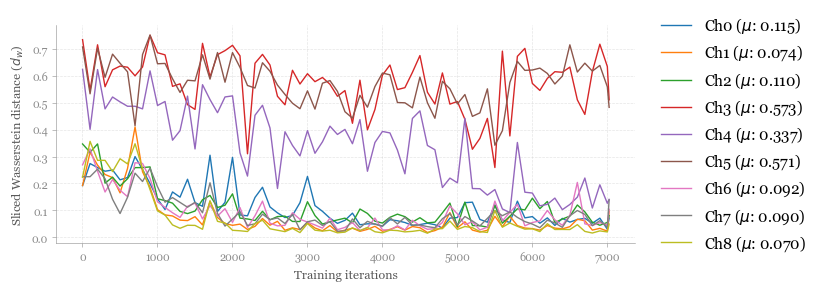

Mean val ms-swd=0.22572217574845677


In [31]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wasserstein_evolution_fixed(csv_path, output_dir):
    # 1. Set font settings globally to Georgia 11pt
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Georgia']
    plt.rcParams['font.size'] = 8

    # 2. Define A4 dimensions in inches (Width: A4, Height: 1/4 A4)
    a4_width = 8.27
    a4_height_quarter = 11.69 / 4.0
    
    # 3. Create figure and axis (No title will be added)
    fig, ax = plt.subplots(figsize=(a4_width, a4_height_quarter))
    
    # 4. Load and filter data
    df = pd.read_csv(csv_path)
    
    # Find and sort only the Wasserstein metric columns
    metric_cols = [col for col in df.columns if str(col).startswith('MS-SWD_Ch')]
    if not metric_cols:
        raise ValueError("No matching 'MS-SWD_Ch' columns found in the CSV.")
        
    metric_cols = sorted(metric_cols, key=lambda x: [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', x)])
    
    # Coerce to numeric and drop rows where metrics weren't calculated (NaNs)
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df_metrics = df.dropna(subset=[metric_cols[0]]).copy()
    
    # Identify the correct x-axis column (fallback to 'update' if 'iteration' isn't explicitly named)
    x_col = 'iteration' if 'iteration' in df.columns else ('update' if 'update' in df.columns else df.columns[0])
    
    # 5. Plot each filtered channel and calculate its mean
    cmap = plt.get_cmap('tab10')
    mean_vals=[]
    
    for i, col in enumerate(metric_cols):
        mean_val = df_metrics[col].mean()
        color = cmap(i % 10)
        
        # Plot line with the mean included in the label for the legend
        ax.plot(
            df_metrics[x_col], 
            df_metrics[col], 
            color=color,
            linewidth=1.0,
            label=f"{col.split('_')[-1]} ($\mu$: {mean_val:.3f})"
        )
        mean_vals.append(mean_val)
        print(mean_val)
    
    # 6. Formatting
    ax.set_ylabel(r"Sliced Wasserstein distance ($d_w$)")
    ax.set_xlabel("Training iterations")
    
    # Optional: Add gridlines for readability, as in your original function
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    
    # Place legend cleanly outside the plot area on the right
    ax.legend(
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5), 
        frameon=False, 
        fontsize=11
    )
    
    # 7. Save and display
    os.makedirs(output_dir, exist_ok=True)
    output_save_path = os.path.join(output_dir, "wasserstein_evolution_filtered_plot.png")
    
    plt.tight_layout()
    plt.savefig(output_save_path, dpi=400, bbox_inches='tight')
    plt.show()

    print(f"Mean val ms-swd={np.mean(mean_vals)}")

# --- Execution ---
gan_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
absolute_csv_path = os.path.abspath(os.path.join(gan_dir, "fluvgan_1_training_1_architecture_4_dcgan_one_hot_all_1_history.csv"))
output_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots"

plot_wasserstein_evolution_fixed(absolute_csv_path, output_dir)

## **Figure 4.7: 2D slices**

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16544\3349819930.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Master plot with multi-tier discrete legends saved to:
c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\model_comparison_stacked_legends.png


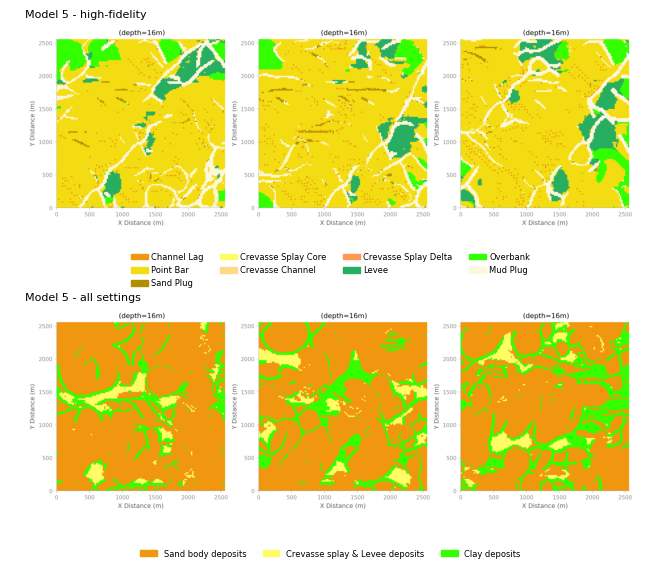

In [ ]:
# ==========================================
# 1. MANUAL PATH DEFINITIONS
# ==========================================
base_dir = r"c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots"

image_paths = [
    os.path.join(base_dir, "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2", "combined_grid_gan_Z_3samples.png"),
    os.path.join(base_dir, "25_epochs_3_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_all_settings", "combined_grid_gan_Z_3samples.png")
]

row_titles = [
    "Model 5 - high-fidelity",
    "Model 5 - all settings"
]

# ==========================================
# 2. DICTIONARIES & LEGEND PATCHES SETUP
# ==========================================
# High-Fidelity Properties dictionary (ignoring undefined/0 for clean legends if needed)
FACIES_PROPERTIES = {
    'channel_lag':         {'val': 1,  'color': "#f1970f", 'description': "Active channel fill, coarse-grained"},
    'point_bar':           {'val': 2,  'color': "#f3dd12", 'description': "Lower energy channel margins"},
    'sand_plug':           {'val': 3,  'color': "#af8f00", 'description': "Fine-grained oxbow/plug fill"},
    'crevasse_splay_core': {'val': 4,  'color': "#fffc65", 'description': "Proximal high-energy splay"},
    'crevasse_channel':    {'val': 5,  'color': "#ffd986", 'description': "Feeder channel for splays"},
    'crevasse_splay_delta':{'val': 6,  'color': "#ff9853", 'description': "Distal fan-like splay deposit"},
    'levee':               {'val': 7,  'color': "#27ae60", 'description': "Sand/silt ridges bordering channel"},
    'overbank':            {'val': 8,  'color': "#33ff00", 'description': "Stabilized/vegetated levee"},
    'mud_plug':            {'val': 9,  'color': "#fff7db", 'description': "Fine silts/clays far from channel"}
}

high_fid_patches = [
    mpatches.Patch(color=info['color'], label=name.replace('_', ' ').title())
    for name, info in FACIES_PROPERTIES.items()
]

# Simplified 3-class settings legend
legend_config_3_classes = {
    'names': {1: 'Sand body deposits', 4: 'Crevasse splay & Levee deposits', 8: 'Clay deposits'},
    'colors': {1: '#f1970f', 4: '#fffc65', 8: '#33ff00'}
}
simplified_patches = [
    mpatches.Patch(color=legend_config_3_classes['colors'][key], label=legend_config_3_classes['names'][key])
    for key in legend_config_3_classes['names'].keys()
]

# ==========================================
# 3. PLOTTING WITH ADVANCED GRIDSPEC INTERFACES
# ==========================================
fig = plt.figure(figsize=(8.27, 7))

# We define 4 rows: Plot 1, Legend 1 (High-Fid), Plot 2, Legend 2 (All Settings)
# height_ratios give the legends smaller relative vertical track limits
gs = gridspec.GridSpec(4, 1, figure=fig, height_ratios=[1, 0.1, 1, 0.11], hspace=0.25)

# ---- ROW 1: High Fidelity Plot ----
ax0 = fig.add_subplot(gs[0, 0])
if os.path.exists(image_paths[0]):
    ax0.imshow(mpimg.imread(image_paths[0]))
ax0.axis('off')
ax0.set_title(row_titles[0], loc='left', fontsize=8, pad=6)

# ---- ROW 2: High Fidelity Legend (Cleanly embedded underneath Row 1) ----
ax_leg1 = fig.add_subplot(gs[1, 0])
ax_leg1.axis('off')  # Hidden subplot space to host the legend boundary safely
ax_leg1.legend(
    handles=high_fid_patches,
    loc='center',
    ncol=4,             # Wrapped into 4 clean columns to fit horizontal space comfortably
    frameon=False,
    fontsize=6,
    labelspacing=0.5,
    handletextpad=0.4
)

# ---- ROW 3: All Settings Plot ----
ax2 = fig.add_subplot(gs[2, 0])
if os.path.exists(image_paths[1]):
    ax2.imshow(mpimg.imread(image_paths[1]))
ax2.axis('off')
ax2.set_title(row_titles[1], loc='left', fontsize=8, pad=6)

# ---- ROW 4: All Settings Legend (Embedded safely underneath Row 3) ----
ax_leg2 = fig.add_subplot(gs[3, 0])
ax_leg2.axis('off')
ax_leg2.legend(
    handles=simplified_patches,
    loc='center',
    ncol=3,
    frameon=False,
    fontsize=6
)

# Adjust layout boundaries tightly without colliding text tracks
plt.tight_layout()

output_path = os.path.join(base_dir, "model_comparison_stacked_legends.png")
plt.savefig(output_path, dpi=400, bbox_inches='tight')
print(f"Master plot with multi-tier discrete legends saved to:\n{output_path}")

plt.show()